# Config B — Frozen CLIP ViT-B/32 + Frozen BLIP-2 2.7B (α sweep)
**No fine-tuning | Cross-modal fusion | FAISS HNSW | Dual T4 | bfloat16**

**Key difference from Config B:** CLIP ViT-B/32 (512-d) instead of ViT-L/14 (768-d).  
**Reuses:** `caption_cache.json` from Config B — BLIP-2 is **not re-run**.

Pipeline:
1. YOLO crop
2. Load pre-computed BLIP-2 captions from `caption_cache.json` (skip re-captioning)
3. CLIP ViT-B/32 visual embedding + CLIP ViT-B/32 text embedding of caption
4. Fuse: `v = α·ϕ_V(x̂) + (1−α)·ϕ_T(c)` for two chosen α values
5. FAISS HNSW index per α
6. Evaluate Recall@K, NDCG@K, mAP@K for each α

## 0. Install dependencies

In [1]:
%%capture
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q faiss-cpu
%pip install ultralytics
!pip install -q Pillow opencv-python-headless

## 1. Imports & Config

In [13]:
import os, json, gc, warnings
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
import torch
import clip
import faiss
from ultralytics import YOLO

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
DATASET_BASE   = Path('/kaggle/input/datasets/venkat96r/vr-inshop-dataset/img')
IMG_ROOT       = DATASET_BASE
PARTITION_FILE = DATASET_BASE / 'list_eval_partition.txt'
YOLO_WEIGHTS   = '/kaggle/input/datasets/harshitkrishnar/yolo-vr/best_yolo_fine_tuned_without_augmenatation.pt'

# ── Reuse caption cache from Config B (no BLIP-2 needed!) ──────────────────
CAPTION_CACHE  = Path('/kaggle/input/datasets/harshitkrishnar/caption-cache/caption_cache.json')  # ← adjust to your dataset slug
# If you uploaded caption_cache.json as a Kaggle dataset, point here.
# Alternatively: CAPTION_CACHE = Path('/kaggle/working/caption_cache.json')

# ── Hyperparams ───────────────────────────────────────────────────────────────
CLIP_MODEL    = 'ViT-B/32'          # ← Changed from ViT-L/14
CLIP_DIM      = 512                  # ViT-B/32 output dim (was 768 for ViT-L/14)
CLIP_BATCH    = 256                  # Larger batch OK: B/32 uses ~3× less VRAM than L/14
TOP_K         = [5, 10, 15]
ALPHA_VALUES  = [0.7, 0.3]
FAISS_M       = 32
FAISS_EF      = 200
DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_GPUS      = torch.cuda.device_count()
DTYPE         = torch.bfloat16

print(f'Device: {DEVICE} | GPUs: {NUM_GPUS} | dtype: {DTYPE}')
print(f'CLIP model: {CLIP_MODEL} | embedding dim: {CLIP_DIM}')

Device: cuda | GPUs: 2 | dtype: torch.bfloat16
CLIP model: ViT-B/32 | embedding dim: 512


## 2. Parse Dataset Split

In [14]:
def parse_partition(partition_file: Path, img_root: Path):
    train, query, gallery = [], [], []
    with open(partition_file, 'r') as f:
        lines = f.read().splitlines()
    for line in lines[2:]:
        parts = line.split()
        if len(parts) < 3:
            continue
        rel_path = parts[0]
        item_id  = parts[1]
        split    = parts[2].lower().strip()
        abs_path = img_root / rel_path
        entry = (str(abs_path), item_id)
        if split == 'train':
            train.append(entry)
        elif split == 'query':
            query.append(entry)
        elif split == 'gallery':
            gallery.append(entry)
    return train, query, gallery

train_data, query_data, gallery_data = parse_partition(PARTITION_FILE, IMG_ROOT)

print(f'✅ Parsed Successfully!')
print(f'Train: {len(train_data)} | Query: {len(query_data)} | Gallery: {len(gallery_data)}')
if gallery_data:
    print(f'Sample Path: {gallery_data[0][0]}')
    print(f'File Exists: {os.path.exists(gallery_data[0][0])}')

✅ Parsed Successfully!
Train: 25882 | Query: 14218 | Gallery: 12612
Sample Path: /kaggle/input/datasets/venkat96r/vr-inshop-dataset/img/img/WOMEN/Blouses_Shirts/id_00000001/02_1_front.jpg
File Exists: True


## 3. Load YOLO

In [15]:
yolo = YOLO(YOLO_WEIGHTS)
yolo.to(DEVICE)
print('YOLO loaded')

def yolo_crop(img_path: str, conf_thresh: float = 0.25) -> Image.Image:
    img = Image.open(img_path).convert('RGB')
    results = yolo(img_path, conf=conf_thresh, verbose=False)
    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return img
    best_idx = boxes.conf.argmax().item()
    x1, y1, x2, y2 = boxes.xyxy[best_idx].cpu().numpy().astype(int)
    x1, y1 = max(0, x1), max(0, y1)
    crop = img.crop((x1, y1, x2, y2))
    return crop if crop.width > 10 and crop.height > 10 else img

YOLO loaded


## 4. Load CLIP ViT-B/32
No BLIP-2 needed — captions are loaded from cache.

In [16]:
print(f'Loading CLIP {CLIP_MODEL}...')
clip_model, clip_preprocess = clip.load(CLIP_MODEL, device=DEVICE)
clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad_(False)

print(f'CLIP {CLIP_MODEL} loaded | embed dim: {clip_model.visual.output_dim}')
assert clip_model.visual.output_dim == CLIP_DIM, \
    f'Unexpected dim: {clip_model.visual.output_dim} vs expected {CLIP_DIM}'

gc.collect()
torch.cuda.empty_cache()

Loading CLIP ViT-B/32...
CLIP ViT-B/32 loaded | embed dim: 512


## 5. Load Pre-computed BLIP-2 Captions from Cache
Skips BLIP-2 inference entirely — reuses `caption_cache.json` from Config B run.

In [17]:
print(f'Loading caption cache from: {CAPTION_CACHE}')
assert CAPTION_CACHE.exists(), (
    f'Caption cache not found at {CAPTION_CACHE}. '
    'Upload caption_cache.json from the Config B run as a Kaggle dataset '
    'and update the CAPTION_CACHE path above.'
)

with open(CAPTION_CACHE, 'r') as f:
    caption_cache: dict = json.load(f)

print(f'✅ Loaded {len(caption_cache):,} cached captions')

# Verify coverage against query + gallery
all_paths = set(p for p, _ in query_data + gallery_data)
missing = all_paths - set(caption_cache.keys())
print(f'Coverage: {len(all_paths) - len(missing)}/{len(all_paths)} paths found in cache')
if missing:
    print(f'⚠️  {len(missing)} paths missing from cache — will use empty string fallback')

Loading caption cache from: /kaggle/input/datasets/harshitkrishnar/caption-cache/caption_cache.json
✅ Loaded 26,830 cached captions
Coverage: 26830/26830 paths found in cache


## 6. Build Fused Embeddings (CLIP ViT-B/32)
For each image: YOLO crop → CLIP visual embed + CLIP text embed of cached caption → fuse.

In [18]:
@torch.no_grad()
def embed_dataset(data: list, desc: str) -> tuple[np.ndarray, list]:
    """
    Returns:
        vis_embs  : (N, CLIP_DIM) float32 — L2-normalised visual embeddings
        txt_embs  : (N, CLIP_DIM) float32 — L2-normalised text embeddings
        ids       : list of item_ids (length N)
    """
    paths  = [p  for p, _ in data]
    ids    = [id_ for _, id_ in data]
    N      = len(paths)

    vis_embs = np.zeros((N, CLIP_DIM), dtype=np.float32)
    txt_embs = np.zeros((N, CLIP_DIM), dtype=np.float32)

    for start in tqdm(range(0, N, CLIP_BATCH), desc=desc):
        batch_paths   = paths[start : start + CLIP_BATCH]
        batch_size    = len(batch_paths)

        # ── Visual branch ────────────────────────────────────────────────────
        imgs = []
        for p in batch_paths:
            try:
                crop = yolo_crop(p)
                imgs.append(clip_preprocess(crop))
            except Exception:
                imgs.append(clip_preprocess(Image.new('RGB', (224, 224))))

        img_tensor = torch.stack(imgs).to(DEVICE)       # (B, 3, 224, 224)
        v = clip_model.encode_image(img_tensor).float()  # (B, 512)
        v = v / v.norm(dim=-1, keepdim=True)
        vis_embs[start : start + batch_size] = v.cpu().numpy()

        # ── Text branch (cached captions) ─────────────────────────────────
        captions = [caption_cache.get(p, '') for p in batch_paths]
        tokens   = clip.tokenize(captions, truncate=True).to(DEVICE)
        t = clip_model.encode_text(tokens).float()       # (B, 512)
        t = t / t.norm(dim=-1, keepdim=True)
        txt_embs[start : start + batch_size] = t.cpu().numpy()

    return vis_embs, txt_embs, ids


print('Embedding gallery...')
gal_vis, gal_txt, gal_ids = embed_dataset(gallery_data, desc='Gallery ViT-B/32')
print(f'Gallery done: {gal_vis.shape}')

print('Embedding queries...')
qry_vis, qry_txt, qry_ids = embed_dataset(query_data, desc='Query ViT-B/32')
print(f'Queries done: {qry_vis.shape}')

Embedding gallery...


Gallery ViT-B/32:   0%|          | 0/50 [00:00<?, ?it/s]

Gallery done: (12612, 512)
Embedding queries...


Query ViT-B/32:   0%|          | 0/56 [00:00<?, ?it/s]

Queries done: (14218, 512)


## 7. Save Raw Embeddings & IDs

In [19]:
OUT_DIR = Path('/kaggle/working')

np.save(OUT_DIR / 'gal_vis_C.npy', gal_vis)
np.save(OUT_DIR / 'gal_txt_C.npy', gal_txt)
np.save(OUT_DIR / 'qry_vis_C.npy', qry_vis)
np.save(OUT_DIR / 'qry_txt_C.npy', qry_txt)

with open(OUT_DIR / 'gal_ids_C.json', 'w') as f:
    json.dump(gal_ids, f)
with open(OUT_DIR / 'qry_ids_C.json', 'w') as f:
    json.dump(qry_ids, f)

print('Raw embeddings saved.')

Raw embeddings saved.


## 8. Build FAISS HNSW Indexes & Search (per α)

In [21]:
def build_and_search(alpha: float, gal_vis, gal_txt, qry_vis, qry_txt, top_k_max: int = 20):
    """
    Fuse embeddings, build HNSW index, search top-K.
    Returns I: (num_queries, top_k_max) indices into gallery.
    """
    # Fuse
    gal_fused = alpha * gal_vis + (1 - alpha) * gal_txt   # (G, 512)
    qry_fused = alpha * qry_vis + (1 - alpha) * qry_txt   # (Q, 512)

    # Re-normalise after fusion
    gal_norms = np.linalg.norm(gal_fused, axis=1, keepdims=True)
    qry_norms = np.linalg.norm(qry_fused, axis=1, keepdims=True)
    gal_fused = gal_fused / np.maximum(gal_norms, 1e-8)
    qry_fused = qry_fused / np.maximum(qry_norms, 1e-8)

    dim = gal_fused.shape[1]  # 512 for ViT-B/32

    # Build HNSW (Inner Product after normalisation ≡ cosine)
    index = faiss.IndexHNSWFlat(dim, FAISS_M, faiss.METRIC_INNER_PRODUCT)
    index.hnsw.efConstruction = FAISS_EF
    index.hnsw.efSearch       = FAISS_EF
    index.add(gal_fused.astype(np.float32))

    # Search
    _, I = index.search(qry_fused.astype(np.float32), top_k_max)
    return I, gal_fused, qry_fused, index


results_per_alpha = {}
for alpha in ALPHA_VALUES:
    print(f'\n── α = {alpha} ──')
    I, gal_f, qry_f, idx = build_and_search(
        alpha, gal_vis, gal_txt, qry_vis, qry_txt, top_k_max=max(TOP_K)
    )
    results_per_alpha[alpha] = I

    # Save per-alpha outputs (consistent naming with Config B)
    alpha_tag = str(alpha).replace('.', '')
    np.save(OUT_DIR / f'gallery_ids_C_{alpha}.npy',  np.array(gal_ids))
    np.save(OUT_DIR / f'query_ids_C_{alpha}.npy',    np.array(qry_ids))
    np.save(OUT_DIR / f'query_embs_C_{alpha}.npy',   qry_f)
    faiss.write_index(idx, str(OUT_DIR / f'gallery_index_C_{alpha}.faiss'))
    print(f'  Saved index and arrays for α={alpha}')


── α = 0.7 ──
  Saved index and arrays for α=0.7

── α = 0.3 ──
  Saved index and arrays for α=0.3


## 9. Evaluate Recall@K, NDCG@K, mAP@K

In [22]:
from collections import Counter

def recall_at_k(retrieved_ids, true_id, k):
    return int(any(r == true_id for r in retrieved_ids[:k]))

def ndcg_at_k(retrieved_ids, true_id, k, total_relevant):
    dcg = sum(
        1.0 / np.log2(rank + 1)
        for rank, rid in enumerate(retrieved_ids[:k], 1)
        if rid == true_id
    )
    ideal_hits = min(total_relevant, k)
    idcg = sum(1.0 / np.log2(r + 1) for r in range(1, ideal_hits + 1))
    return dcg / idcg if idcg > 0 else 0.0

def ap_at_k(retrieved_ids, true_id, k, total_relevant):
    hits, ap = 0, 0.0
    for rank, rid in enumerate(retrieved_ids[:k], 1):
        if rid == true_id:
            hits += 1
            ap += hits / rank
    return ap / total_relevant if total_relevant > 0 else 0.0

def evaluate(I, qry_ids, gal_ids, top_k_list):
    gal_ids_arr = np.array(gal_ids)
    gal_id_counts = Counter(gal_ids)
    metrics = {k: {'recall': [], 'ndcg': [], 'map': []} for k in top_k_list}
    for qi, (row, qid) in enumerate(zip(I, qry_ids)):
        retrieved = gal_ids_arr[row].tolist()
        total_relevant = gal_id_counts[qid]
        for k in top_k_list:
            metrics[k]['recall'].append(recall_at_k(retrieved, qid, k))
            metrics[k]['ndcg'].append(ndcg_at_k(retrieved, qid, k, total_relevant))
            metrics[k]['map'].append(ap_at_k(retrieved, qid, k, total_relevant))
    return {
        k: {
            'Recall@K': np.mean(metrics[k]['recall']),
            'NDCG@K':   np.mean(metrics[k]['ndcg']),
            'mAP@K':    np.mean(metrics[k]['map']),
        }
        for k in top_k_list
    }

all_results = {}
for alpha in ALPHA_VALUES:
    print(f'\n── Evaluating α = {alpha} ──')
    I = results_per_alpha[alpha]
    res = evaluate(I, qry_ids, gal_ids, TOP_K)
    all_results[str(alpha)] = res
    for k, m in res.items():
        print(f'  @{k}: Recall={m["Recall@K"]:.4f}  NDCG={m["NDCG@K"]:.4f}  mAP={m["mAP@K"]:.4f}')

with open(OUT_DIR / 'results_config_C.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print('\n✅ Results saved to results_config_C.json')


── Evaluating α = 0.7 ──
  @5: Recall=0.5162  NDCG=0.2552  mAP=0.1711
  @10: Recall=0.5907  NDCG=0.2621  mAP=0.1823
  @15: Recall=0.6337  NDCG=0.2708  mAP=0.1871

── Evaluating α = 0.3 ──
  @5: Recall=0.4539  NDCG=0.2225  mAP=0.1492
  @10: Recall=0.5348  NDCG=0.2319  mAP=0.1604
  @15: Recall=0.5779  NDCG=0.2407  mAP=0.1651

✅ Results saved to results_config_C.json


## 10. Visual Sanity Check — Sample Retrieval

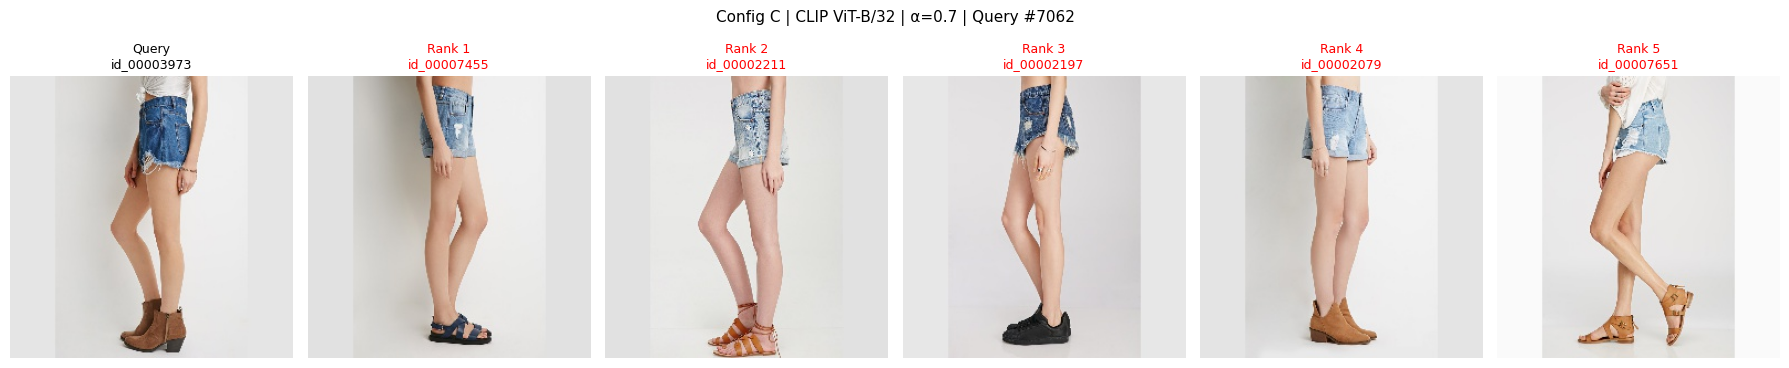

Saved sample retrieval image.


In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

SAMPLE_IDX = 7062 % len(query_data)   # match Config B sample index
ALPHA_VIZ  = ALPHA_VALUES[0]          # use first alpha for viz

I_viz = results_per_alpha[ALPHA_VIZ]
gal_ids_arr = np.array(gal_ids)

q_path, q_id = query_data[SAMPLE_IDX]
top5_indices = I_viz[SAMPLE_IDX, :5]
top5_paths   = [gallery_data[i][0] for i in top5_indices]
top5_ids     = gal_ids_arr[top5_indices].tolist()

fig, axes = plt.subplots(1, 6, figsize=(18, 4))
axes[0].imshow(Image.open(q_path))
axes[0].set_title(f'Query\n{q_id}', fontsize=9)
axes[0].axis('off')

for ax, path, rid in zip(axes[1:], top5_paths, top5_ids):
    ax.imshow(Image.open(path))
    color = 'green' if rid == q_id else 'red'
    ax.set_title(f'Rank {list(top5_ids).index(rid)+1}\n{rid}', fontsize=9, color=color)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

fig.suptitle(f'Config C | CLIP ViT-B/32 | α={ALPHA_VIZ} | Query #{SAMPLE_IDX}', fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / f'sample_retrieval_C_{SAMPLE_IDX}.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved sample retrieval image.')

## 11. Config B vs C Summary Table

In [ ]:
# # Load Config B results for comparison (if available)
# config_b_path = Path('/kaggle/input/config-b-outputs/results_config_B.json')
# if config_b_path.exists():
#     with open(config_b_path) as f:
#         results_b = json.load(f)
#     print('Config B results loaded for comparison.')
# else:
#     results_b = None
#     print('Config B results not found — skipping comparison.')

# print('\n' + '='*70)
# print(f'{"Config":<12} {"α":<6} {"K":<5} {"Recall@K":<12} {"NDCG@K":<12} {"mAP@K":<10}')
# print('='*70)

# for alpha in ALPHA_VALUES:
#     for k in TOP_K:
#         c = all_results[str(alpha)][k]
#         print(f'{"C (ViT-B/32)":<12} {alpha:<6} {k:<5} {c["Recall@K"]:<12.4f} {c["NDCG@K"]:<12.4f} {c["mAP@K"]:<10.4f}')

# if results_b:
#     print('-'*70)
#     for alpha in ALPHA_VALUES:
#         alpha_key = str(alpha)
#         if alpha_key not in results_b:
#             continue
#         for k_str, m in results_b[alpha_key].items():
#             k = int(k_str)
#             print(f'{"B (ViT-L/14)":<12} {alpha:<6} {k:<5} {m["Recall@K"]:<12.4f} {m["NDCG@K"]:<12.4f} {m["mAP@K"]:<10.4f}')

# print('='*70)